>## Importing Packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### Step2: Load DataSet

In [2]:
df=pd.read_csv("Heart Disease Data.csv")
df.sample(6)

,gender,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
3516,male,40,Yes,15.0,No,No,No,No,211.0,122.0,81.0,30.55,75.0,91.0,No
3532,male,44,Yes,3.0,No,No,Yes,No,352.0,164.0,119.0,28.92,73.0,72.0,Yes
3604,female,42,No,0.0,No,Yes,No,No,206.0,101.0,75.0,18.73,55.0,84.0,No
3276,male,61,Yes,20.0,No,No,No,No,260.0,115.0,79.0,23.65,56.0,78.0,No
2532,female,41,No,0.0,No,No,Yes,No,317.0,149.5,93.0,35.42,68.0,87.0,No
1927,female,42,Yes,25.0,No,No,No,No,286.0,133.5,80.0,26.25,75.0,65.0,No


### Step3: Data Processing 
Perform data preprocessing tasks such as handling missing values , encoding categorical values , and feature scaling 

In [3]:
df.shape

(4240, 15)

In [4]:
df.isnull().sum()

gender               0
age                  0
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [5]:
df.sample(4)

,gender,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
3683,male,57,Yes,20.0,No,No,No,No,260.0,123.0,73.0,27.51,65.0,83.0,Yes
850,male,39,Yes,40.0,No,No,No,No,207.0,131.0,82.0,24.25,73.0,83.0,No
263,male,64,No,0.0,No,No,Yes,No,217.0,147.0,87.0,29.73,77.0,NaN,No
593,female,46,Yes,5.0,No,No,No,No,220.0,123.0,88.0,32.49,94.0,79.0,Yes


In [6]:
## Filling the categorical values with the most frequent value (Mode)

mode_value = df['BPMeds'].mode()[0]   # mode()[0]: Retrieves the first value from the list of modes. If there are multiple modes, it will return the first one.
df['BPMeds'] = df['BPMeds'].fillna(mode_value)      #fillna(): Fills missing values in a column with a specified value. 

In [7]:
## Filling the Numerical values with the middle value when the data is sorted (Median)
numeric_cols = [ "cigsPerDay", "totChol" ,"BMI" , "heartRate" , "glucose"]
for col in numeric_cols:
    median_value = df[col].median()
    df[col].fillna( median_value, inplace=True)

In [8]:
df.isnull().sum()

gender             0
age                0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [9]:
df["TenYearCHD"].value_counts()

TenYearCHD
No     3596
Yes     644
Name: count, dtype: int64

In [10]:
df.dtypes

gender              object
age                  int64
currentSmoker       object
cigsPerDay         float64
BPMeds              object
prevalentStroke     object
prevalentHyp        object
diabetes            object
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD          object
dtype: object

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           4240 non-null   object 
 1   age              4240 non-null   int64  
 2   currentSmoker    4240 non-null   object 
 3   cigsPerDay       4240 non-null   float64
 4   BPMeds           4240 non-null   object 
 5   prevalentStroke  4240 non-null   object 
 6   prevalentHyp     4240 non-null   object 
 7   diabetes         4240 non-null   object 
 8   totChol          4240 non-null   float64
 9   sysBP            4240 non-null   float64
 10  diaBP            4240 non-null   float64
 11  BMI              4240 non-null   float64
 12  heartRate        4240 non-null   float64
 13  glucose          4240 non-null   float64
 14  TenYearCHD       4240 non-null   object 
dtypes: float64(7), int64(1), object(7)
memory usage: 497.0+ KB


In [12]:
df.describe()

,age,cigsPerDay,totChol,sysBP,diaBP,BMI,heartRate,glucose
count,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000
mean,49.580189,8.944340,236.667689,132.354599,82.897759,25.799005,75.878774,81.600943
std,8.572942,11.904777,44.328480,22.033300,11.910394,4.070775,12.023937,22.860340
min,32.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000
25%,42.000000,0.000000,206.000000,117.000000,75.000000,23.077500,68.000000,72.000000
50%,49.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000
75%,56.000000,20.000000,262.000000,144.000000,90.000000,28.032500,83.000000,85.000000
max,70.000000,70.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.sample(2)

,gender,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
3061,male,50,No,0.0,No,No,Yes,No,239.0,148.5,100.0,27.83,80.0,90.0,No
907,female,43,Yes,20.0,No,No,No,No,201.0,129.0,92.0,24.54,88.0,63.0,No


> No Duplicate Value In The Dataset 

## Perform the some basic visulaization on the dataset
"" TO understand the pattern and trends in the dataset""

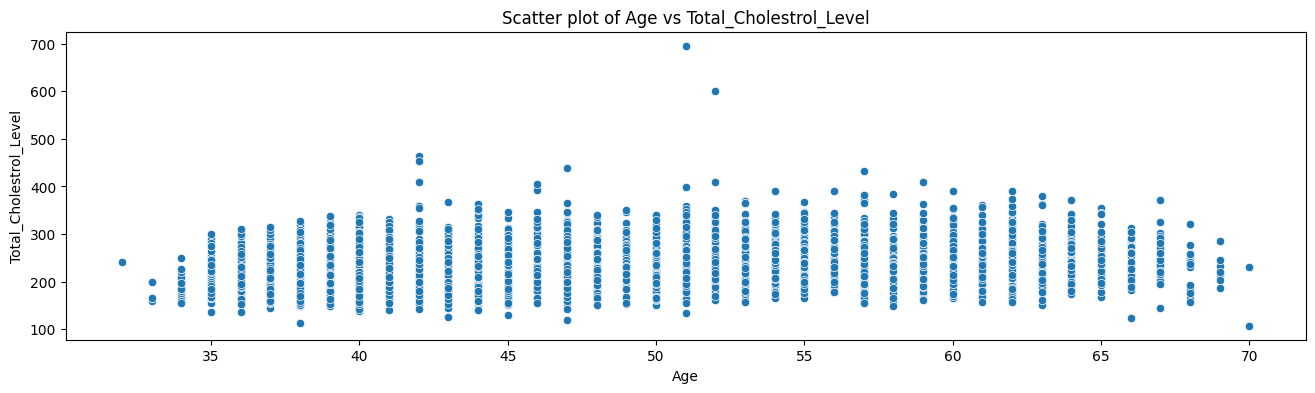

Description: This scatter plot shows the relationship between Age and Total_Cholestrol_Level for the individuals in the dataset.


In [15]:
# Scatter plot of income vs credit score
plt.figure(figsize=(16, 4))
sns.scatterplot(x="age", y="totChol", data=df)
plt.title('Scatter plot of Age vs Total_Cholestrol_Level')
plt.xlabel('Age')
plt.ylabel('Total_Cholestrol_Level')
plt.show()
print("Description: This scatter plot shows the relationship between Age and Total_Cholestrol_Level for the individuals in the dataset.")

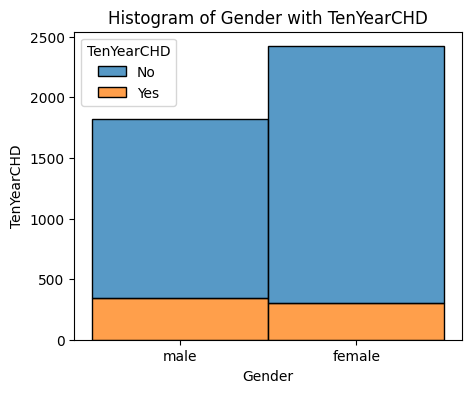

Description: This histogram shows the distribution of gender in the dataset, with different colors representing the Ten_Year_Chronary_Heart_Disease (Yes or No)


In [16]:
# Histogram of gender with loan status hue
plt.figure(figsize=(5, 4))
sns.histplot(x="gender", data=df, hue="TenYearCHD", multiple="stack")
plt.title('Histogram of Gender with TenYearCHD')
plt.xlabel('Gender')
plt.ylabel('TenYearCHD')
plt.show()
print("Description: This histogram shows the distribution of gender in the dataset, with different colors representing the Ten_Year_Chronary_Heart_Disease (Yes or No)") 

<Axes: xlabel='heartRate', ylabel='Count'>

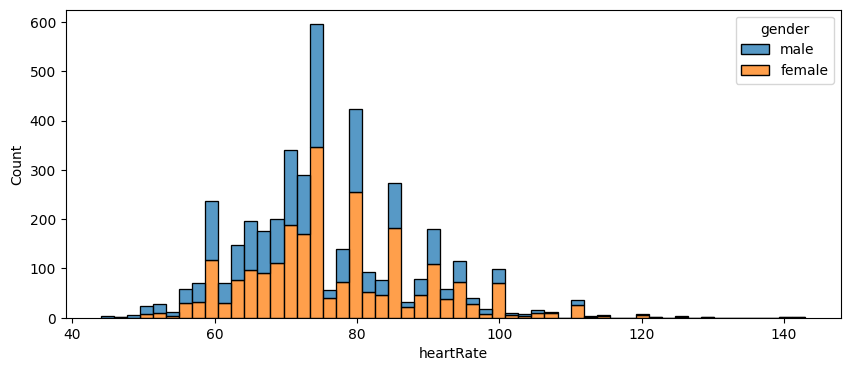

In [17]:
plt.figure(figsize=(10, 4))
sns.histplot(x="heartRate", data=df, hue="gender", multiple="stack")

In [18]:
cat = df.select_dtypes(include=['object'])               # This will show how many categorical columns we have 
num = df.select_dtypes(include=['int64', 'float64'])     # This will show how many numerical columns we have 
print("Categorical columns: ", cat.columns)
print("Numerical columns: ", num.columns)

Categorical columns:  Index(['gender', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp',
       'diabetes', 'TenYearCHD'],
      dtype='object')
Numerical columns:  Index(['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate',
       'glucose'],
      dtype='object')


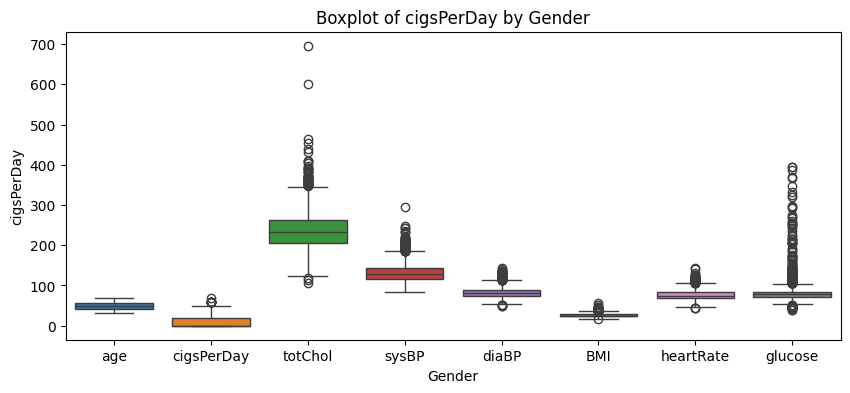

Description: This boxplot shows the distribution of cigsPerDay by gender in the dataset. , to see the outliers


In [19]:
# Create the boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(num)
plt.title('Boxplot of cigsPerDay by Gender')
plt.xlabel('Gender')
plt.ylabel('cigsPerDay')
plt.show()
print("Description: This boxplot shows the distribution of cigsPerDay by gender in the dataset. , to see the outliers")

In [20]:
## function for handling outliers
def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    median = df[column].median()
    df[column] = np.where(df[column].values > upper_bound, median, df[column])
    df[column] = np.where(df[column].values < lower_bound, median, df[column])

# function call
handle_outliers(df, 'cigsPerDay')
handle_outliers(df, 'totChol')
handle_outliers(df, 'sysBP')
handle_outliers(df, 'diaBP')
handle_outliers(df, 'BMI')
handle_outliers(df, 'heartRate')
handle_outliers(df, 'glucose')

<Axes: >

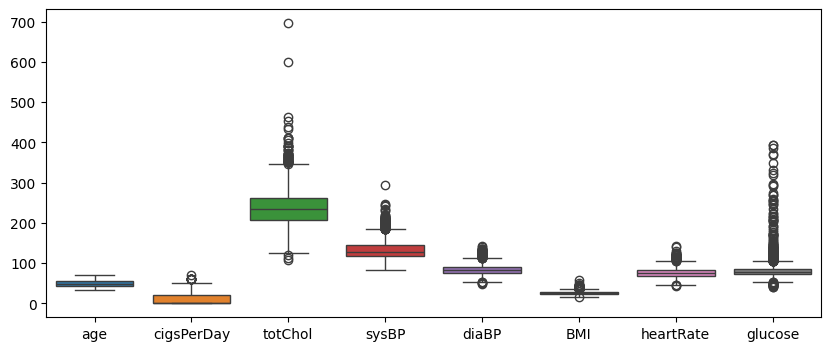

In [21]:
plt.figure(figsize=(10, 4))
sns.boxplot(num)

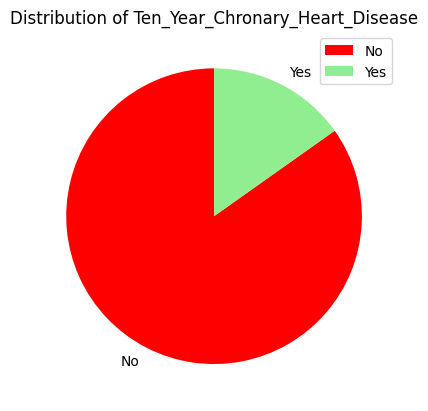

Description: This piechart shows the occurrence of Yes and No in the  10 years CHD Columns  
TenYearCHD
No     3596
Yes     644
Name: count, dtype: int64


In [22]:
counts = df["TenYearCHD"].value_counts()
plt.pie(counts, labels=['No','Yes'],startangle=90 , colors =["red","lightgreen"])
plt.title("Distribution of Ten_Year_Chronary_Heart_Disease")
plt.legend(counts.index)
plt.show()
print("Description: This piechart shows the occurrence of Yes and No in the  10 years CHD Columns  ")
print(counts)

### Types of columns in the data set 

In [23]:
cat = df.select_dtypes(include=['object'])               # This will show how many categorical columns we have 
num = df.select_dtypes(include=['int64', 'float64'])     # This will show how many numerical columns we have 
print("Categorical columns: ", cat.columns)
print("Numerical columns: ", num.columns)

Categorical columns:  Index(['gender', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp',
       'diabetes', 'TenYearCHD'],
      dtype='object')
Numerical columns:  Index(['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate',
       'glucose'],
      dtype='object')


### Encode binary variables into label encoder(e.g 0/1 columns)

In [24]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for col in cat:  # Here we applying for loop in above cat variables to convert categorical variable to numerical  
    df[col] = label_encoder.fit_transform(df[col])
df.head(3)
   

,gender,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0


#### here we draw the heatmap for checking the correlation between each column

<Axes: >

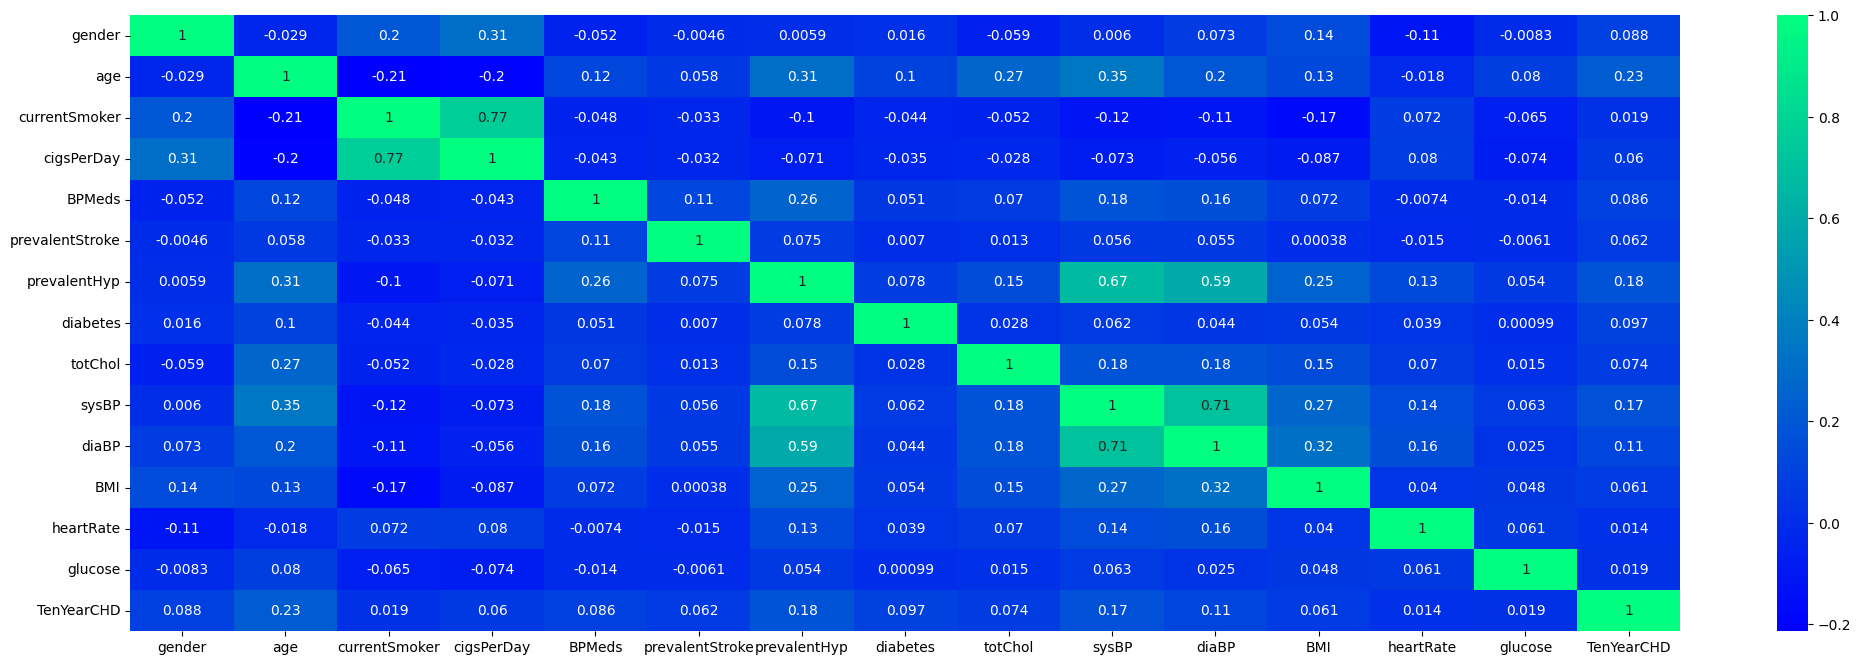

In [25]:
plt.figure(figsize = (25,8)) # Set figure size (width * height )
corr = df.corr()
sns.heatmap(corr,annot=True,cmap="winter")  

#####            strong positive correlation
      1.Heatmap shows currentSmoker and cigsPerDay which was ---> (+0.76)
      2.Heatmap shows sysBP and diaBP which was ---> (+0.78)
 #####          moderate positive correlation
     1.Heatmap shows prevalentHyp and sysBP	which was --->  (+0.7)
     2.Heatmap shows prevalentHyp and diaBP which was --->  (+0.62)
     3.Heatmap shows diabetes and glucose which was --->  (+0.61)
     4.Heatmap shows age and sysBPs which was --->  (+0.39)
#####             Weak Correlation
      1. Gender with age --->(-0.029)
      2. Gender with prevalentStroke --->(-0.0046)
      3. age with heartRate --->(0.013)

### Split the dataset into training and testing sets 

In [26]:
X = df.drop("TenYearCHD",axis=1) ## Here we select our TenYearCHD column as a output column and remaining 
y = df["TenYearCHD"]           ##  --column as input columns so here we drop from x and assign to y 


In [27]:
## Split the data into trainig and testing and import library of sklearn

from sklearn.model_selection import train_test_split
X_train ,X_test ,y_train ,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [28]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3180 entries, 1413 to 860
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           3180 non-null   int64  
 1   age              3180 non-null   int64  
 2   currentSmoker    3180 non-null   int64  
 3   cigsPerDay       3180 non-null   float64
 4   BPMeds           3180 non-null   int64  
 5   prevalentStroke  3180 non-null   int64  
 6   prevalentHyp     3180 non-null   int64  
 7   diabetes         3180 non-null   int64  
 8   totChol          3180 non-null   float64
 9   sysBP            3180 non-null   float64
 10  diaBP            3180 non-null   float64
 11  BMI              3180 non-null   float64
 12  heartRate        3180 non-null   float64
 13  glucose          3180 non-null   float64
dtypes: float64(7), int64(7)
memory usage: 372.7 KB


### Standardize  Scaling features for logistic regression 

In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
X_train

array([[ 1.15459464, -1.2369729 ,  0.98625794, ..., -0.43339696,
        -0.96284359,  2.12280545],
       [-0.86610484, -0.76866242, -1.01393354, ..., -1.76233114,
        -0.13663355,  0.2078243 ],
       [-0.86610484, -0.76866242, -1.01393354, ...,  0.14065668,
        -1.14644582, -0.11133923],
       ...,
       [-0.86610484,  1.22165708, -1.01393354, ..., -0.12340799,
         0.6895765 ,  0.31421214],
       [ 1.15459464, -1.2369729 ,  0.98625794, ..., -0.29275382,
        -0.68744024, -1.70715685],
       [-0.86610484, -1.70528337, -1.01393354, ..., -1.40067735,
         1.33218431,  0.2078243 ]])

### Model Development 

> 1. **logistic regression**

In [31]:
from sklearn.linear_model import LogisticRegression 
lg = LogisticRegression()
lg.fit(X_train,y_train)
lg_predict_train = lg.predict(X_train)

lg_predict =lg.predict(X_test)


In [32]:
lg_predict

array([0, 0, 0, ..., 0, 0, 0])

> **Accracy score** **,** **classification_report**  **,**  **confusion_matrix**  

In [33]:
from sklearn .metrics import accuracy_score ,classification_report ,confusion_matrix 
print("Accuracy Score Is tarin :",accuracy_score(y_train,lg_predict_train))


print("Accuracy Score Is:",accuracy_score(y_test,lg_predict))
print("\n Classification Report:\n", classification_report(y_test,lg_predict))
print("\n Confusion Matrix:", confusion_matrix(y_test,lg_predict))

Accuracy Score Is tarin : 0.8503144654088051
Accuracy Score Is: 0.8594339622641509

 Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.99      0.92       905
           1       0.65      0.08      0.15       155

    accuracy                           0.86      1060
   macro avg       0.76      0.54      0.54      1060
weighted avg       0.83      0.86      0.81      1060


 Confusion Matrix: [[898   7]
 [142  13]]


> 2. **Random Forest classifier**

In [34]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
rf_pred =rf.predict(X_test)

In [35]:
rf_pred

array([0, 0, 0, ..., 0, 0, 0])

> **Accracy score** **,** **classification_report**  **,**  **confusion_matrix**  

In [36]:
from sklearn .metrics import accuracy_score ,classification_report ,confusion_matrix 

print("Accuracy Score Is:",accuracy_score(y_test,rf_pred))
print("\n Classification Report:\n", classification_report(y_test,rf_pred))
print("\n Confusion Matrix:", confusion_matrix(y_test,rf_pred))

Accuracy Score Is: 0.8547169811320755

 Classification Report:
               precision    recall  f1-score   support

           0       0.86      1.00      0.92       905
           1       0.56      0.03      0.06       155

    accuracy                           0.85      1060
   macro avg       0.71      0.51      0.49      1060
weighted avg       0.81      0.85      0.80      1060


 Confusion Matrix: [[901   4]
 [150   5]]


> 3. **SVC (Support Vector Classifier)**

In [37]:
from sklearn.svm import SVC
svc_model = SVC()
svc_model.fit(X_train ,y_train)
svc_pre = svc_model.predict(X_test)

In [38]:
svc_pre

array([0, 0, 0, ..., 0, 0, 0])

> **Accracy score** **,** **classification_report**  **,**  **confusion_matrix**  

In [39]:
from sklearn .metrics import accuracy_score ,classification_report ,confusion_matrix 

print("Accuracy Score Is:",accuracy_score(y_test,svc_pre))
print("\n Classification Report:\n", classification_report(y_test,svc_pre))
print("\n Confusion Matrix:", confusion_matrix(y_test,svc_pre))

Accuracy Score Is: 0.8537735849056604

 Classification Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92       905
           1       0.50      0.01      0.01       155

    accuracy                           0.85      1060
   macro avg       0.68      0.50      0.47      1060
weighted avg       0.80      0.85      0.79      1060


 Confusion Matrix: [[904   1]
 [154   1]]


> 4. **(KNN) K--Nearest Neighbors**

In [40]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)
knn_pre =knn.predict(X_test)

In [41]:
knn_pre

array([0, 0, 0, ..., 0, 0, 0])

> **Accracy score** **,** **classification_report**  **,**  **confusion_matrix**  

In [42]:
from sklearn .metrics import accuracy_score ,classification_report ,confusion_matrix 

print("Accuracy Score Is:",accuracy_score(y_test,knn_pre))
print("\n Classification Report:\n", classification_report(y_test,knn_pre))
print("\n Confusion Matrix:", confusion_matrix(y_test,knn_pre))

Accuracy Score Is: 0.8386792452830188

 Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.97      0.91       905
           1       0.25      0.05      0.09       155

    accuracy                           0.84      1060
   macro avg       0.55      0.51      0.50      1060
weighted avg       0.77      0.84      0.79      1060


 Confusion Matrix: [[881  24]
 [147   8]]


> 5. **Decision Tree**

In [43]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)
dec_pred = dt.predict(X_test)

In [44]:
dec_pred

array([0, 0, 0, ..., 0, 1, 0])

> **Accracy score** **,** **classification_report**  **,**  **confusion_matrix**

In [45]:
from sklearn .metrics import accuracy_score ,classification_report ,confusion_matrix 

print("Accuracy Score Is:",accuracy_score(y_test,dec_pred))
print("\n Classification Report:\n", classification_report(y_test,dec_pred))
print("\n Confusion Matrix:", confusion_matrix(y_test,dec_pred))

Accuracy Score Is: 0.7556603773584906

 Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.84      0.85       905
           1       0.22      0.26      0.24       155

    accuracy                           0.76      1060
   macro avg       0.54      0.55      0.55      1060
weighted avg       0.77      0.76      0.76      1060


 Confusion Matrix: [[761 144]
 [115  40]]


> 6. **Naive Bayes**

In [46]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train , y_train)
nb_pred = nb.predict(X_test)

In [47]:
nb_pred

array([0, 0, 0, ..., 0, 0, 0])

> **Accracy score** **,** **classification_report**  **,**  **confusion_matrix**  

In [48]:
from sklearn .metrics import accuracy_score ,classification_report ,confusion_matrix 

print("Accuracy Score Is:",accuracy_score(y_test,nb_pred))
print("\n Classification Report:\n", classification_report(y_test,nb_pred))
print("\n Confusion Matrix:", confusion_matrix(y_test,nb_pred))

Accuracy Score Is: 0.8415094339622642

 Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91       905
           1       0.40      0.17      0.24       155

    accuracy                           0.84      1060
   macro avg       0.64      0.56      0.57      1060
weighted avg       0.80      0.84      0.81      1060


 Confusion Matrix: [[866  39]
 [129  26]]


In [49]:
from sklearn.metrics import accuracy_score , f1_score , precision_score , recall_score
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'SVC': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Gaussian Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier()
}

# Train and evaluate models
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    prd = model.predict(X_train)
    acc = accuracy_score(y_train , prd)

    
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    results.append([name , acc, accuracy, f1, precision, recall])
    

# Create DataFrame from results
results_df = pd.DataFrame(results, columns=['Model','Train_Acuracy', 'Test_Accuracy', 'F1-score', 'Precision', 'Recall'])

# Print the DataFrame
results_df

,Model,Train_Acuracy,Test_Accuracy,F1-score,Precision,Recall
0,Logistic Regression,0.850314,0.859434,0.148571,0.650000,0.083871
1,Random Forest,1.000000,0.856604,0.061728,0.714286,0.032258
2,SVC,0.851572,0.853774,0.012739,0.500000,0.006452
3,K-Nearest Neighbors,0.865409,0.838679,0.085561,0.250000,0.051613
4,Gaussian Naive Bayes,0.828931,0.841509,0.236364,0.400000,0.167742
5,Decision Tree,1.000000,0.753774,0.220896,0.205556,0.238710


#### Uing Pickle Library To Save This Model

In [50]:
import pickle 
pickle.dump(lg,open("Heart_Disease_Model.pkl","wb"))
pickle.dump(scaler,open("Heart_Disease_Scaler.pkl","wb"))


## Predicitive System For Checking How The Model Is Working 

In [51]:
    # First we define the function for columns in which we are working 
def predictive(gender, age, currentSmoker, cigsPerDay, BPMeds, prevalentStroke, prevalentHyp, diabetes, totChol, 
               sysBP, diaBP, BMI, heartRate, glucose):
    
    ## Encode the categorical columns 
     gender_encoded = 1 if gender =="Male" else 0          # Then we encode the columns which are categorical I have only one categorical column 
     currentSmoker_encoded = 1 if currentSmoker =="Yes" else 0 
     BPMeds_encoded = 1 if BPMeds =="Yes" else 0 
     prevalentStroke_encoded = 1 if prevalentStroke	=="Yes" else 0 
     prevalentHyp_encoded = 1 if prevalentHyp =="Yes" else 0 
     diabetes_encoded = 1 if diabetes =="Yes" else 0 

    ## Prepare Features Array 
     features = np.array([[gender, age, currentSmoker , cigsPerDay, BPMeds, prevalentStroke, prevalentHyp, diabetes, totChol, sysBP, 
                          diaBP, BMI, heartRate, glucose]])  # Then we convert are columns to 2d array 
    
    ## Scalling
     scaled_features = scaler.transform(features)            # Then we do transform features columns 

    ## Predict by model
     result = lg.predict(scaled_features)                  # Atlast we finally predict the model by logisicRegression 
     return result[0]

In [52]:
df.sample(4)

,gender,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
1890,0,50,0,0.0,0,0,0,0,225.0,132.0,81.0,23.62,74.0,103.0,0
4117,1,47,0,0.0,0,0,1,0,283.0,146.5,97.5,26.25,66.0,73.0,0
1399,1,63,1,20.0,0,0,1,0,252.0,149.0,90.0,33.49,82.0,83.0,0
3491,1,54,1,3.0,0,0,0,0,173.0,121.0,79.0,26.21,75.0,68.0,0


In [54]:
"""# Test 1 In this test we have pass all the input variables to 2nd row value of the dataset to see how our model is predicting our output value :

gender = float(input("Choose the Gender As \n 1 for Male: \n 0 for Female:"))
age = int(input("Enter the Age :"))               
currentSmoker = float(input("Choose the currentSmoker As \n 1 for Yes: \n 0 for No:"))     
cigsPerDay  = float(input("Enter the No. of cigarettes smoked per day :")) 
BPMeds  = float(input("Choose whether the individual is on Blood Pressure Medication  He/She take  As \n 1 for Yes: \n 0 for No:"))  
prevalentStroke = float(input("Choose whether the individual has had a prevalentStroke or not   As \n 1 for Yes: \n 0 for No:")) 
prevalentHyp = float(input("Choose  whether the individual has HyperTension or not  As \n 1 for Yes: \n 0 for No:")) 
diabetes  = float(input("Choose the Person has diabetes or not  As \n 1 for Yes: \n 0 for No:"))   
totChol = float(input("Enter the Total Cholestrol level :"))     
sysBP  = float(input("Enter the Systolic Blood Pressure :"))     
diaBP = float(input("Enter the Diastolic Blood Pressure :"))   
BMI  = float(input("Enter the Body Mass Index  :"))    
heartRate = float(input("Enter the Heart Rate :"))  
glucose  = float(input("Enter the Glucose Level  :")) 

result =predictive(gender, age, currentSmoker, cigsPerDay, BPMeds, prevalentStroke, prevalentHyp, diabetes, totChol, 
                                        sysBP, diaBP, BMI, heartRate, glucose)
if result == 1:
    print("Person has a heart disease :")
else:
    print("Person do not has a heart disease :")"""

'# Test 1 In this test we have pass all the input variables to 2nd row value of the dataset to see how our model is predicting our output value :\n\ngender = float(input("Choose the Gender As \n 1 for Male: \n 0 for Female:"))\nage = int(input("Enter the Age :"))               \ncurrentSmoker = float(input("Choose the currentSmoker As \n 1 for Yes: \n 0 for No:"))     \ncigsPerDay  = float(input("Enter the No. of cigarettes smoked per day :")) \nBPMeds  = float(input("Choose whether the individual is on Blood Pressure Medication  He/She take  As \n 1 for Yes: \n 0 for No:"))  \nprevalentStroke = float(input("Choose whether the individual has had a prevalentStroke or not   As \n 1 for Yes: \n 0 for No:")) \nprevalentHyp = float(input("Choose  whether the individual has HyperTension or not  As \n 1 for Yes: \n 0 for No:")) \ndiabetes  = float(input("Choose the Person has diabetes or not  As \n 1 for Yes: \n 0 for No:"))   \ntotChol = float(input("Enter the Total Cholestrol level :"))    

In [55]:
df.sample(4)

,gender,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
3373,1,51,0,0.0,0,0,0,0,154.0,98.0,66.0,22.86,63.0,82.0,0
4033,0,49,1,15.0,0,0,0,0,233.0,112.5,80.0,27.87,96.0,80.0,0
322,0,53,1,20.0,0,0,0,0,240.0,131.0,82.0,24.22,66.0,80.0,0
1665,1,50,1,30.0,0,0,0,0,258.0,124.0,78.0,24.33,72.0,83.0,0


##### > So here we can see our model is predicting true value as a output so we can say our model is working good 

### Model Completion Succesfully

 Model has been trained and saved successfully.

---> The dataset has been cleaned and preprocessed.

---> The dataset has been split into training and testing sets with a test size of 25%.

---> Logistic Regression ,Random Forest ,Support Vector Classoifier ,K-Nearest Neighbors  ,Decision Tree  ,Naive Bayes have been evaluated using accuracy_score ,r2_score ,mean_absolute_error ,classification_report ,confusion_matrix.

---> The model with the highest accuracy score is approximately **85%**

---> The model can now be used to predict Heart_Disease based on the provided features.

---> The model has been saved to a pickle file named "Heart_Disease_Model.pkl". 

--->This file can be used to load the trained model and make predictions on new data.

> **Now Model Is Ready To Host** 